In [4]:
%pip install --upgrade pip

     ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
     ------------------------ --------------- 1.1/1.8 MB 33.9 MB/s eta 0:00:01
     ---------------------------------------- 1.8/1.8 MB 38.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.


In [ ]:
! pip install numpy pandas matplotlib seaborn librosa pillow scikit-learn tensorflow image lightgbm xgboost

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.9 MB 38.8 MB/s eta 0:00:01
     --------------- ------------------------ 4.9/12.9 MB 51.7 MB/s eta 0:00:01
     -------------------------- ------------- 8.4/12.9 MB 60.2 MB/s eta 0:00:01
     ------------------------------ -------- 10.2/12.9 MB 54.5 MB/s eta 0:00:01
     ----------------------------------- --- 11.9/12.9 MB 54.7 MB/s eta 0:00:01
     --------------------------------------  12.9/12.9 MB 50.4 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 38.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
     -------------- ------------------------- 4.1/11.3 MB 86.7 MB/s eta 0:00:01
     -------------------------- ------------- 7.4/11.3 MB 95.3 MB/s eta 0:00:01
     --------------------------------------  11.3/11.3 MB 72.6 MB/s eta 0:00:01
     --------------------------------------- 11.3/11.3 M


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip list

Package            Version
------------------ ------------
absl-py            2.5.0
asgiref            3.12.1
asttokens          3.0.2
astunparse         1.6.3
audioread          3.1.0
certifi            2026.7.22
cffi               2.1.1
charset-normalizer 3.5.1
colorama           0.4.6
comm               0.2.3
contourpy          1.3.2
cycler             0.12.1
debugpy            1.8.21
decorator          5.3.1
Django             5.2.17
exceptiongroup     1.3.1
executing          2.2.1
flatbuffers        25.12.19
fonttools          4.63.0
gast               0.7.0
google-pasta       0.2.0
grpcio             1.83.1
h5py               3.14.0
idna               3.19
image              1.5.33
ipykernel          7.3.0
ipython            8.39.0
jedi               0.20.0
joblib             1.5.3
jupyter_client     8.10.0
jupyter_core       5.9.1
keras              3.12.4
kiwisolver         1.5.1
lazy-loader        0.5
libclang           18.1.1
librosa            0.11.0
llvmlite           0.49

# 1. 환경 설정

In [1]:
import os                           # 폴더 / 파일 경로 처리
import glob                         # 특정 패턴의 파일 검색 (예: .wav .mp3 등)
import random                       # 랜덤 샘플 선택

import numpy as np                  # 오디오 파형, 행렬 계산
import pandas as pd                 # 데이터프레임
import matplotlib.pyplot as plt     # 그래프 (시각화)
import seaborn as sns               # confusion matrix 등 시각화
%matplotlib inline

import librosa                      # wav 로딩, waveform, FFT/STFT, Mel Spectrogram, MFCC 등 대부분 처리
import librosa.display

import joblib

from sklearn.metrics import (       # 모델 성능 평가
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 머신러닝 3종
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 분할
from sklearn.model_selection import train_test_split

# 딥러닝 (CNN, CRNN, MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================
# Path
# =========================

BASE_DIR = os.getcwd()                                      # Jupyter Notebook에서 현재 작업 디렉토리 확인
AUDIO_DIR = os.path.join(BASE_DIR, 'audio')                 # 원본 / 전처리 Audio Data 위치
MODEL_DIR = os.path.join(BASE_DIR, 'models')                # 모델 저장 위치 (딥러닝 3, 머신러닝 3)

print('BASE_DIR : ', BASE_DIR)
print('AUDIO_DIR : ', AUDIO_DIR)
print('MODEL_DIR : ', MODEL_DIR)

# =========================
# Classes
# =========================

CLASSES = ['wasp', 'bee', 'other']

# =========================
# Audio
# =========================

SR = 24000                              # 샘플 레이트
DURATION = 2.0                          # 오디오 샘플 길이 (초)
SAMPLES_PER_TRACK = int(SR * DURATION)  # 오디오 샘플 수
TARGET_DB = -20.0                       # 볼륨 정규화 기준 (dB)

# =========================
# Mel-Spectrogram
# =========================

# 이미지 크기
IMG_HEIGHT = 128
IMG_WIDTH = 128

N_FFT = 1024                            # FFT 윈도우 크기
HOP_LENGTH = 256                        # hop length (윈도우 이동 간격)
N_MELS = 128                            # mel 스펙트로그램의 mel 밴드 수

# =========================
# Training
# ========================

BATCH_SIZE = 16
EPOCHS = 50

BASE_DIR :  e:\AI_First_Team_Project\Buzz\ai_model
AUDIO_DIR :  e:\AI_First_Team_Project\Buzz\ai_model\audio
MODEL_DIR :  e:\AI_First_Team_Project\Buzz\ai_model\models


# 2. 데이터셋 확인 및 기본 유틸리티

In [3]:
# 지정한 디렉토리가 존재하지 않으면 생성
def ensure_directory_exists(dir_path):
    os.makedirs(dir_path, exist_ok=True)

# 오디오 폴더와 클래스별 하위 폴더가 존재하는지 확인
def validate_audio_directory_structure(audio_dir, classes):
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[Error] Audio 루트 폴더를 찾을 수 없습니다. : {audio_dir}")
    
    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[Error] Class 폴더를 찾을 수 없습니다. : {class_dir}")

# 클래스 별 오디오 파일 개수를 집계하여 dict 형태로 반환
def count_audio_files(audio_dir, classes, extension = '*.wav'):
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts

# 각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
def validate_minimum_files_per_class(file_counts, minimum_count = 10):
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(f"[Error] Class '{cls}'의 Audio 파일 개수가 최소 요구량({minimum_count})보다 적습니다.")

# 오디오 속성 검증
def validate_audio_properties(audio_dir, classes, target_sr = 48000, target_duration = DURATION):
    invalid_files = []

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)

        for file_path in glob.glob(os.path.join(class_dir, '*.wav')):
            y, sr = librosa.load(file_path, sr = None, mono = True)

            duration = len(y) / sr

            if sr != target_sr or abs(duration - target_duration) > 0.01:
                invalid_files.append({
                    'file': file_path,
                    'sr': sr,
                    'duration': duration
                })
    
    return invalid_files

===== 데이터 폴더 및 파일 개수 확인 =====
Audio Root 경로:  e:\AI_First_Team_Project\Buzz\ai_model\audio
Model 저장 경로:  e:\AI_First_Team_Project\Buzz\ai_model\models
   Class  Count     Ratio
0   wasp   1000  0.333333
1    bee   1000  0.333333
2  other   1000  0.333333

전체 Audio 파일 수: 3000


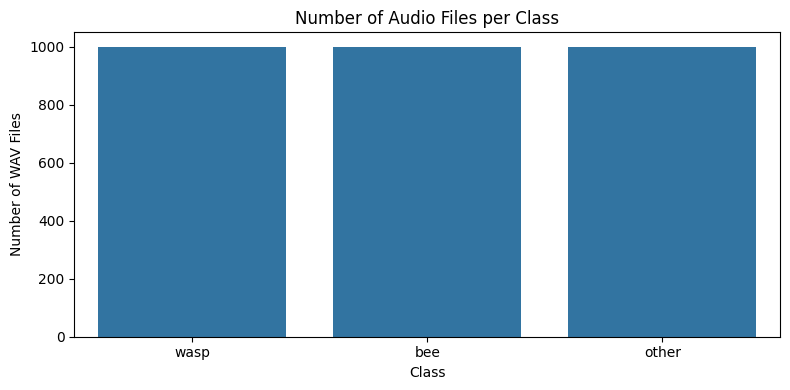

In [4]:
# Audio 폴더와 클래스 별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스 별 wav 파일 개수 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension = '*.wav')

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count = 10)

# 집계 결과를 데이터프레임으로 변환
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=['Class', 'Count'])

# 클래스 별 데이터 비율
file_counts_df['Ratio'] = (file_counts_df['Count'] / file_counts_df['Count'].sum())

# 전체 데이터 수
total_count = file_counts_df['Count'].sum()

# 현재 데이터 구성 상황
print('===== 데이터 폴더 및 파일 개수 확인 =====')
print("Audio Root 경로: ", AUDIO_DIR)
print("Model 저장 경로: ", MODEL_DIR)
print(file_counts_df)
print(f'\n전체 Audio 파일 수: {total_count}')

plt.figure(figsize = (8, 4))
sns.barplot(data = file_counts_df, x = "Class", y = "Count")
plt.title("Number of Audio Files per Class")
plt.xlabel("Class")
plt.ylabel("Number of WAV Files")
plt.tight_layout()
plt.show()

# 3. 오디오 전처리 및 EDA

In [5]:
'''
Audio 파일을 mono 신호로 읽고, 지정 길이와 볼륨으로 정규화한다.

- 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
- Sample Rate를 SR 기준으로 통일한다.
- Stereo 입력은 mono로 변환한다.
- 너무 긴 파일은 랜덤한 위치에서 목표 길이만큼 잘라 사용한다.
- Audio의 RMS 볼륨을 일정 수준으로 정규화한다.
- 너무 짧은 파일은 정규화 후 zero-padding 한다.
- 파일 경로 또는 코덱 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
'''

# Audio RMS 볼륨 정규화
def normalize_rms(y, target_db = TARGET_DB):
    rms = np.sqrt(np.mean(y ** 2))

    # 무음 또는 거의 무음인 경우 정규화하지 않는다.
    if rms < 1e-8:
        return y

    target_rms = 10 ** (target_db / 20)

    y = y * (target_rms / rms)

    # 증폭으로 인한 clipping 방지
    y = np.clip(y, -1.0, 1.0)

    return y

def load_audio_file(file_path, sr = SR, duration = DURATION, target_db = TARGET_DB):
    # 입력 경로 타입 확인
    if not isinstance(file_path, str):
        raise TypeError(f'[Error] file_path는 문자열이어야 합니다.\n현재 타입: {type(file_path)}')

    # 파일 존재 여부 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'[Error] Audio 파일을 찾을 수 없습니다: {file_path}')

    # 지원 확장자 확인
    valid_exts = ['.mp3', '.wav', '.flac', '.ogg', '.m4a']

    ext = os.path.splitext(file_path)[1].lower()

    if ext not in valid_exts:
        raise ValueError(f'[Error] 지원하지 않는 Audio 확장자입니다: {ext}')

    try:
        # 지정 SR로 resampling + mono 변환
        y, sr = librosa.load(file_path, sr = sr, mono = True)
    except Exception as e:
        raise RuntimeError(f'[Error] Audio Load 실패: {file_path}\n원인: {e}')

    # 빈 오디오 검사
    if y is None or len(y) == 0:
        raise ValueError(f'[Error] Audio 파일이 비어있거나 읽을 수 없습니다: {file_path}')

    # 목표 길이 계산
    target_length = int(sr * duration)

    # 긴 파일은 랜덤한 구간 사용
    if len(y) > target_length:
        max_start = len(y) - target_length
        start = random.randint(0, max_start)
        y = y[start:start + target_length]

    # 볼륨 정규화
    y = normalize_rms(y, target_db = target_db)

    # 짧은 파일은 뒤쪽 zero-padding
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode = 'constant')

    return y, sr

In [6]:
sample_files = {}

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, '*.wav')
    files = glob.glob(pattern)

    if len(files) == 0:
        raise FileNotFoundError(f"[Error] Class '{cls}'에 해당하는 Audio 파일을 찾을 수 없습니다.")

    sample_files[cls] = random.choice(files)

for cls, sample_file in sample_files.items():
    y_sample, sr_sample = load_audio_file(sample_file)

    print(f'\n===== {cls} =====')
    print('Sample File: ', sample_file)
    print('Sample Rate: ', sr_sample)
    print('Sample Counts: ', len(y_sample))
    print('Sample Duration(s): ', len(y_sample) / sr_sample)


===== wasp =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\wasp\wasp_0642.wav
Sample Rate:  24000
Sample Counts:  48000
Sample Duration(s):  2.0

===== bee =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\bee\bee_part1_0015.wav
Sample Rate:  24000
Sample Counts:  48000
Sample Duration(s):  2.0

===== other =====
Sample File:  e:\AI_First_Team_Project\Buzz\ai_model\audio\other\drone_0026.wav
Sample Rate:  24000
Sample Counts:  48000
Sample Duration(s):  2.0


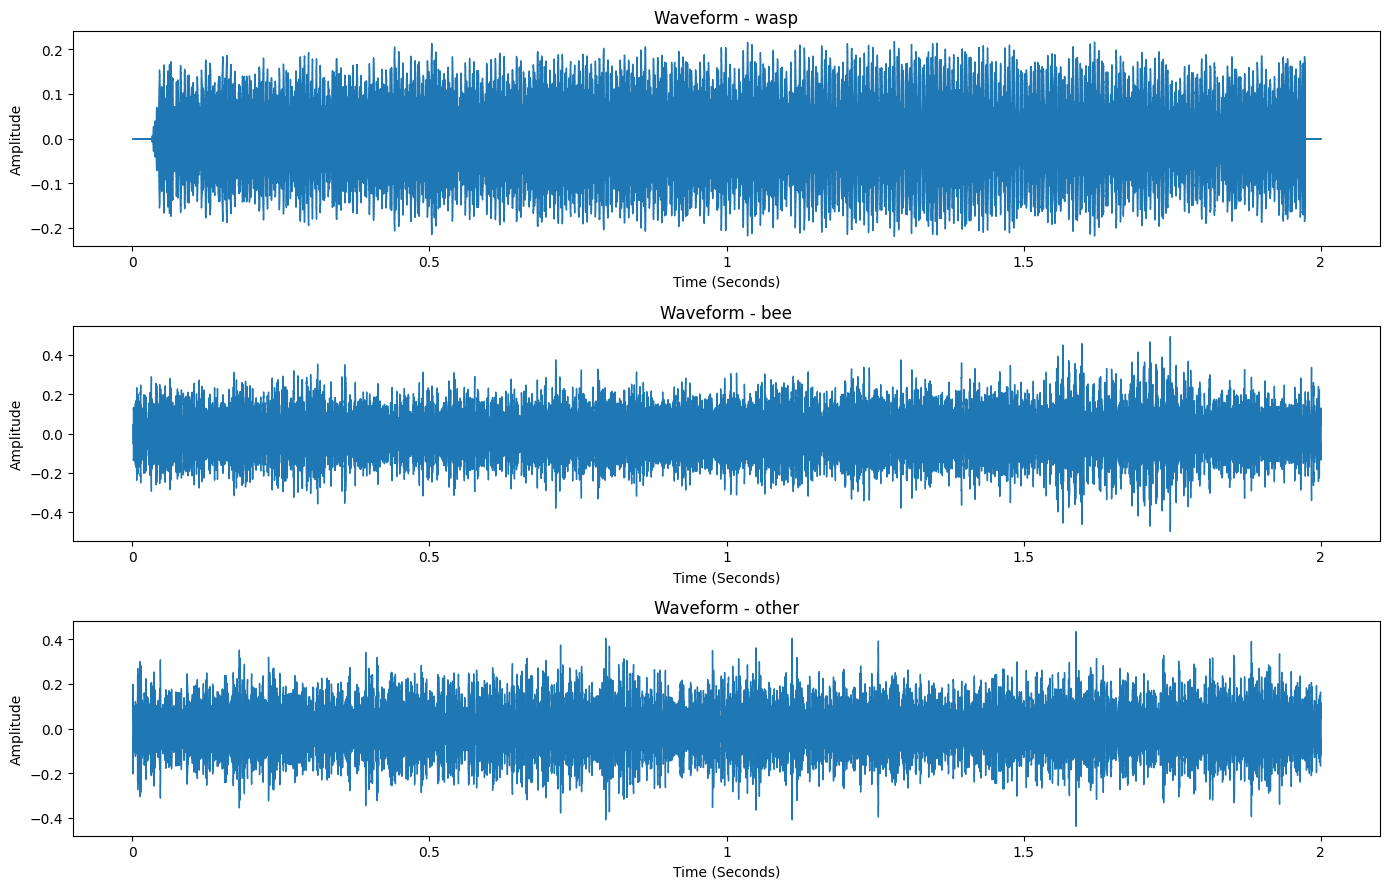

In [7]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    plt.subplot(len(CLASSES), 1, i)

    librosa.display.waveshow(y_sample, sr = sr_sample)

    plt.title(f'Waveform - {cls}')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

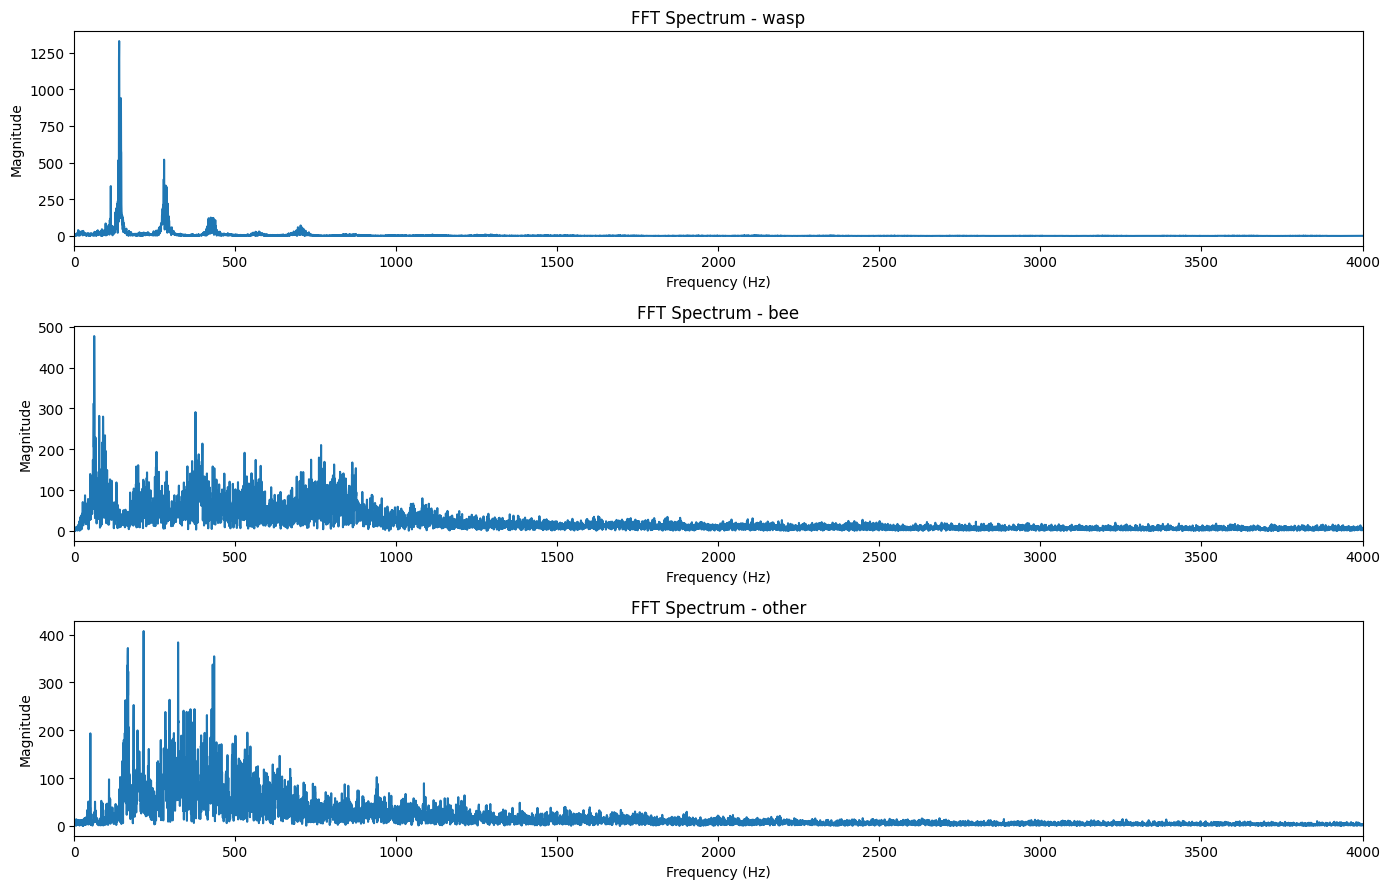

In [8]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # 실수 Audio 신호용 FFT
    fft_sample = np.fft.rfft(y_sample)

    # Magnitude Spectrum
    magnitude_sample = np.abs(fft_sample)

    # Frequency Axis
    freqs_sample = np.fft.rfftfreq(len(y_sample), d = 1 / sr_sample)

    plt.subplot(len(CLASSES), 1, i)

    plt.plot(freqs_sample, magnitude_sample)

    plt.title(f'FFT Spectrum - {cls}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    plt.xlim(0, sr_sample / 6)

plt.tight_layout()
plt.show()

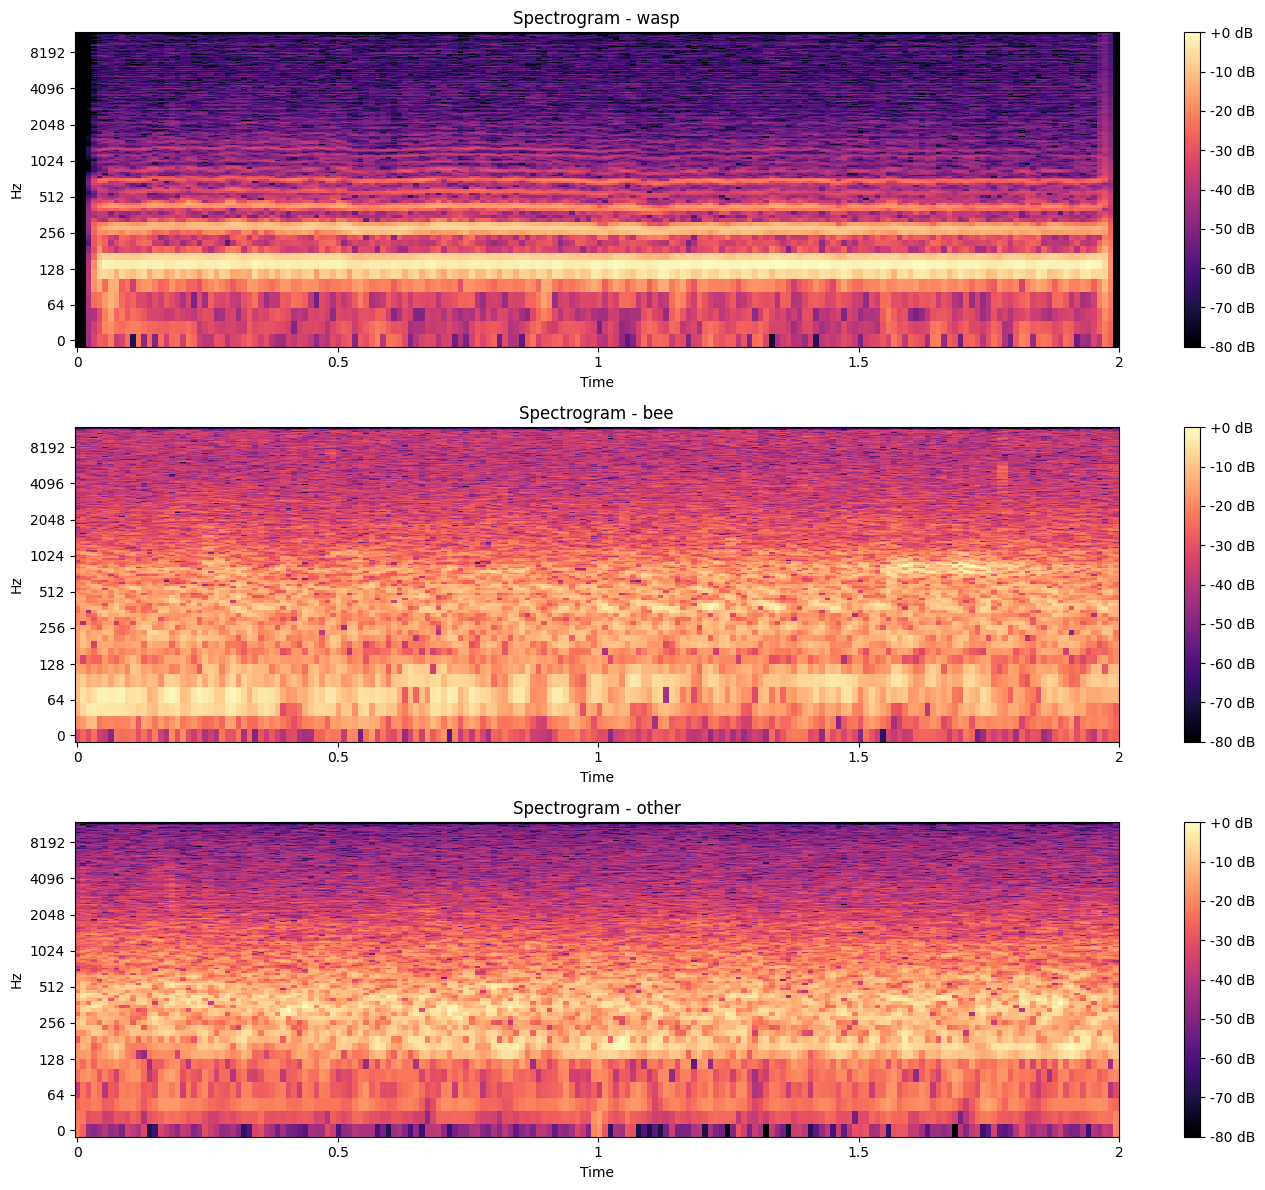

In [9]:
plt.figure(figsize = (14, 12))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # STFT
    stft_sample = librosa.stft(y_sample, n_fft = N_FFT, hop_length = HOP_LENGTH)

    # Magnitude Spectrogram
    spectrogram_sample = np.abs(stft_sample)

    # dB 변환
    spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref = np.max)

    plt.subplot(len(CLASSES), 1, i)

    img = librosa.display.specshow(
        spectrogram_db_sample,
        sr = sr_sample,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log',
        cmap = 'magma'
    )

    plt.colorbar(img, format = '%+2.0f dB')
    plt.title(f'Spectrogram - {cls}')

plt.tight_layout()
plt.show()

# 4. Deep Learning

## 4-1. Mel-Spectrogram 데이터셋 구성

In [10]:
'''
Audio 신호를 Mel-Spectrogram으로 변환한다.

- 이미 전처리된 y, sr을 입력받는다.
- 학습 및 추론 과정에서 동일한 Mel-Spectrogram 생성 방식을 사용한다.
'''

def create_mel_spectrogram_from_audio(y, sr):
    # Mel-Spectrogram 계산
    mel_spec = librosa.feature.melspectrogram(
        y = y,
        sr = sr,
        n_fft = N_FFT,
        hop_length = HOP_LENGTH,
        n_mels = N_MELS,
        power = 2.0
    )

    # Power → dB 변환
    mel_spec_db = librosa.power_to_db(mel_spec, ref = np.max)

    return mel_spec_db

def create_mel_spectrogram(audio_path, sr = SR, duration = DURATION):
    y, sr = load_audio_file(audio_path, sr = sr, duration = duration)
    return create_mel_spectrogram_from_audio(y, sr)

In [11]:
'''
전체 Audio 파일을 순회하며 Mel-Spectrogram Datasets 생성

- PNG 이미지 파일로 저장하지 않고 numpy 배열 형태로 구성한다.
- CNN / MobileNet / CRNN 에서 공통으로 사용할 수 있는 Mel-Spectrogram 원본 데이터를 만든다.
- Class Label과 함께 X, y 형태의 학습 Datasets을 생성한다.
'''

mel_data = []
mel_labels = []
mel_file_paths = []

print('===== Mel-Spectrogram 데이터 생성 시작 =====')

for class_index, cls in enumerate(CLASSES):
    class_audio_dir = os.path.join(AUDIO_DIR, cls)

    # Wav 파일 목록
    audio_files = glob.glob(os.path.join(class_audio_dir, '*.wav'))

    print(f'{cls}: {len(audio_files)}개 파일 처리 중...')

    for audio_file in audio_files:
        try:
            # Mel-Spectrogram 생성
            mel_spec_db = create_mel_spectrogram(audio_file)

            mel_data.append(mel_spec_db)
            mel_labels.append(class_index)
            mel_file_paths.append(audio_file)
        except Exception as e:
            print(f'[Warning] 파일 처리 실패: {audio_file}\n원인: {e}')

print('===== Mel-Spectrogram 데이터 생성 완료 =====')

# numpy 배열로 변환
X_mel = np.array(mel_data, dtype = np.float32)
y_mel = np.array(mel_labels, dtype = np.int32)
mel_file_paths = np.array(mel_file_paths)

print('Mel 데이터 shape: ', X_mel.shape)
print('Label 데이터 shape: ', y_mel.shape)
print('File Path 데이터 shape: ', mel_file_paths.shape)

===== Mel-Spectrogram 데이터 생성 시작 =====
wasp: 1000개 파일 처리 중...
bee: 1000개 파일 처리 중...
other: 1000개 파일 처리 중...
===== Mel-Spectrogram 데이터 생성 완료 =====
Mel 데이터 shape:  (3000, 128, 188)
Label 데이터 shape:  (3000,)
File Path 데이터 shape:  (3000,)


In [12]:
'''
Mel-Spectrogram 배열 데이터를 Train / Val / Test 로 분할

- numpy 배열 자체를 분할한다.
- Class 비율을 유지하기 위해 stratify를 적용한다.
- CNN / MobileNet / CRNN 모두 동일한 Train / Val / Test 데이터를 사용한다.
- 모델 간 비교가 공정하도록 random_state를 고정한다.
'''

# 1차 분할: Train 70%, Temp 30%
(X_train_mel, X_temp_mel, y_train_mel, y_temp_mel, paths_train_mel, paths_temp_mel) = train_test_split(
    X_mel, y_mel, mel_file_paths, test_size = 0.3, stratify = y_mel, random_state = SEED
)

# 2차 분할: Val 15%, Test 15%
(X_val_mel, X_test_mel, y_val_mel, y_test_mel, paths_val_mel, paths_test_mel) = train_test_split(
    X_temp_mel, y_temp_mel, paths_temp_mel, test_size = 0.5, stratify = y_temp_mel, random_state = SEED
)

print('===== Mel-Spectrogram 데이터 분할 완료 =====')
print('Train: ', X_train_mel.shape, y_train_mel.shape, paths_train_mel.shape)
print('Val: ', X_val_mel.shape, y_val_mel.shape, paths_val_mel.shape)
print('Test: ', X_test_mel.shape, y_test_mel.shape, paths_test_mel.shape)

def print_class_distribution(labels, dataset_name):
    unique, counts = np.unique(labels, return_counts = True)

    print(f'\n[{dataset_name}]')

    for label, count in zip(unique, counts):
        print(f'{CLASSES[label]}: {count}개')

print_class_distribution(y_train_mel, 'Train')
print_class_distribution(y_val_mel, 'Val')
print_class_distribution(y_test_mel, 'Test')

===== Mel-Spectrogram 데이터 분할 완료 =====
Train:  (2100, 128, 188) (2100,) (2100,)
Val:  (450, 128, 188) (450,) (450,)
Test:  (450, 128, 188) (450,) (450,)

[Train]
wasp: 700개
bee: 700개
other: 700개

[Val]
wasp: 150개
bee: 150개
other: 150개

[Test]
wasp: 150개
bee: 150개
other: 150개


In [13]:
'''
딥러닝 모델 학습을 위한 Mel-Spectrogram 입력 형태 생성

- CNN 은 1채널 Spectrogram 입력을 사용한다.
- MobileNetV2 는 ImageNet 사전학습 전처리를 적용한 3채널 RGB 입력을 사용한다.
- CRNN 은 시간-주파수 구조를 유지한 1채널 입력을 사용한다.
- CNN / CRNN 은 Mel-Spectrogram dB 값을 0 ~ 1 범위로 정규화한다.
- 동일한 Train / Val / Test Split을 사용하여 모델 간 비교 조건을 통일한다.
'''

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def normalize_mel_db(X):
    # Mel-Spectrogram의 dB 값(-80 ~ 0)을 0 ~ 1 범위로 정규화한다.
    
    X_normalized = (X + 80.0) / 80.0
    X_normalized = np.clip(X_normalized, 0.0, 1.0)

    return X_normalized.astype(np.float32)

def prepare_cnn_dataset(X):
    # Mel-Spectrogram 정규화
    X_normalized = normalize_mel_db(X)

    # 채널 차원 추가
    X_normalized = X_normalized[..., np.newaxis]

    # CNN 입력 크기로 Resize
    X_resized = tf.image.resize(X_normalized, (IMG_HEIGHT, IMG_WIDTH))

    return X_resized.numpy().astype(np.float32)

def prepare_mobilenet_dataset(X):
    # Mel-Spectrogram 정규화
    X_normalized = normalize_mel_db(X)

    # 채널 차원 추가
    X_normalized = X_normalized[..., np.newaxis]

    # MobileNetV2 입력 크기로 Resize
    X_resized = tf.image.resize(X_normalized, (IMG_HEIGHT, IMG_WIDTH))

    # 1채널 → 3채널
    X_rgb = tf.repeat(X_resized, repeats = 3, axis = -1)

    # 0 ~ 1 → 0 ~ 255
    X_rgb = X_rgb * 255.0

    # MobileNetV2 ImageNet 전처리
    X_preprocessed = preprocess_input(X_rgb)

    return X_preprocessed.numpy().astype(np.float32)

def prepare_crnn_dataset(X):
    # Mel-Spectrogram 정규화
    X_normalized = normalize_mel_db(X)

    # 채널 차원 추가
    X_normalized = X_normalized[..., np.newaxis]

    return X_normalized.astype(np.float32)

In [14]:
# CNN
X_train_cnn = prepare_cnn_dataset(X_train_mel)
X_val_cnn = prepare_cnn_dataset(X_val_mel)
X_test_cnn = prepare_cnn_dataset(X_test_mel)

# MobileNetV2
X_train_mobile = prepare_mobilenet_dataset(X_train_mel)
X_val_mobile = prepare_mobilenet_dataset(X_val_mel)
X_test_mobile = prepare_mobilenet_dataset(X_test_mel)

# CRNN
X_train_crnn = prepare_crnn_dataset(X_train_mel)
X_val_crnn = prepare_crnn_dataset(X_val_mel)
X_test_crnn = prepare_crnn_dataset(X_test_mel)

print('===== 딥러닝 입력 shape =====')
print('CNN : ', X_train_cnn.shape)
print('Mobile : ', X_train_mobile.shape)
print('CRNN : ', X_train_crnn.shape)

===== 딥러닝 입력 shape =====
CNN :  (2100, 128, 128, 1)
Mobile :  (2100, 128, 128, 3)
CRNN :  (2100, 128, 188, 1)


In [15]:
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASSES)
}

idx_to_class = {
    idx: cls
    for idx, cls in enumerate(CLASSES)
}

print('class_to_idx: ', class_to_idx)
print('idx_to_class: ', idx_to_class)

class_to_idx:  {'wasp': 0, 'bee': 1, 'other': 2}
idx_to_class:  {0: 'wasp', 1: 'bee', 2: 'other'}


## 4-2. CNN

Mel-Spectrogram을 입력으로 사용하는 CNN 분류 모델을 학습한다.

- 입력: 128 × 128 × 1 Mel-Spectrogram
- 출력 클래스: wasp / bee / other
- 평가 지표: Accuracy, Precision, Recall, Macro F1, Wasp Recall
- 최적 모델은 Validation Loss 기준으로 저장

In [16]:
'''
Mel-Spectrogram 기반 CNN 분류 모델

- 입력 : 128 x 128 크기의 1채널 Mel-Spectrogram
- 출력 : wasp / bee / other 3개 클래스 확률
'''

# CNN 입력 shape
cnn_input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

# CNN 모델 생성
cnn_model = models.Sequential([
    layers.Input(shape = cnn_input_shape),

    # 첫 번째 Convolution Layer
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution Layer
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution Layer
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 특징맵을 하나의 벡터로 축약
    layers.GlobalAveragePooling2D(),

    # 분류층
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(len(CLASSES), activation = 'softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,123 (395.01 KB)

 Trainable params: 101,123 (395.01 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
'''
CNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CNN 모델 저장 경로
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'cnn_best.keras')

# CNN 모델 컴파일
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
cnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Accuracy가 가장 높은 모델 저장
cnn_checkpoint = ModelCheckpoint(
    filepath = CNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CNN Model Path: ', CNN_MODEL_PATH)

CNN Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_best.keras


In [18]:
'''
CNN 모델 학습
'''

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_mel,
    validation_data = (X_val_cnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [cnn_early_stopping, cnn_checkpoint],
    verbose = 1
)

Epoch 1/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4767 - loss: 0.9589
Epoch 1: val_loss improved from None to 0.54735, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.5695 - loss: 0.7863 - val_accuracy: 0.8178 - val_loss: 0.5474
Epoch 2/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7083 - loss: 0.5230
Epoch 2: val_loss improved from 0.54735 to 0.15790, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.8038 - loss: 0.4188 - val_accuracy: 0.9733 - val_loss: 0.1579
Epoch 3/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9469 - loss: 0.1807
Epoch 3: val_loss improved from 0.15790 to 0.11075, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\cnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - accuracy: 0.9357 - loss: 0.2072 - val_accuracy: 0.9733 - val_loss:

In [19]:
def plot_training_history(history, model_name):
    # 학습 정확도 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['accuracy'], label = 'Train Accuracy')
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CNN 학습 손실 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['loss'], label = 'Train Loss')
    plt.plot(history.history['val_loss'], label = 'Validation Loss')

    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
'''
모델 성능 평가 공통 함수

Val / Test 데이터 모두 동일한 방식으로 평가하기 위해 사용
'''

def evaluate_model(y_true, y_pred, model_name, show_report = True):
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average = 'macro',
        zero_division = 0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average = 'macro',
        zero_division = 0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average = 'macro',
        zero_division = 0
    )

    wasp_recall = recall_score(
        y_true,
        y_pred,
        labels = [0],
        average = 'macro',
        zero_division = 0
    )

    if show_report:
        print(f'===== {model_name} 분류 리포트 =====')

        print(classification_report(
            y_true,
            y_pred,
            target_names = CLASSES,
            zero_division = 0
        ))

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        plt.figure(figsize = (7, 6))

        sns.heatmap(
            cm,
            annot = True,
            fmt = 'd',
            cmap = 'Blues',
            xticklabels = CLASSES,
            yticklabels = CLASSES
        )

        plt.title(f'{model_name} Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.show()

        print(f'Accuracy    : {accuracy:.4f}')
        print(f'Precision   : {precision:.4f}')
        print(f'Recall      : {recall:.4f}')
        print(f'Macro F1    : {f1:.4f}')
        print(f'Wasp Recall : {wasp_recall:.4f}')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Macro F1': f1,
        'Wasp Recall': wasp_recall
    }

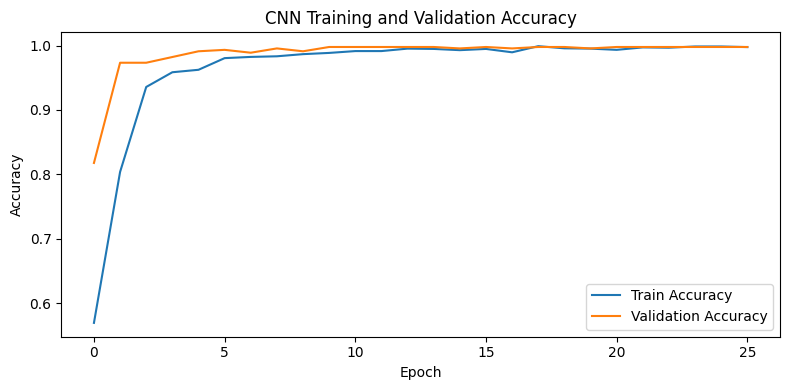

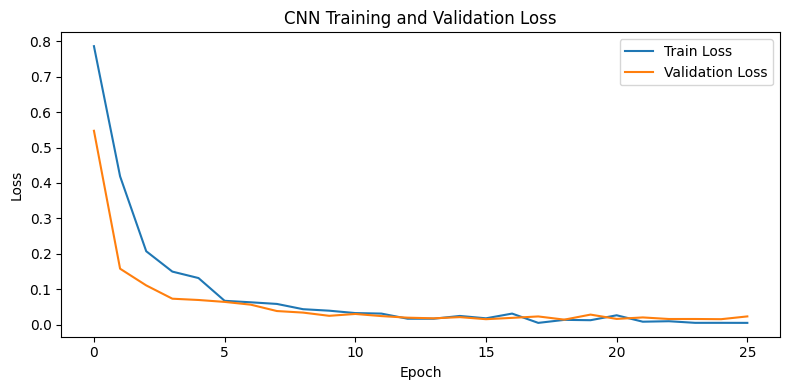

===== CNN 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       0.99      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      0.99      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



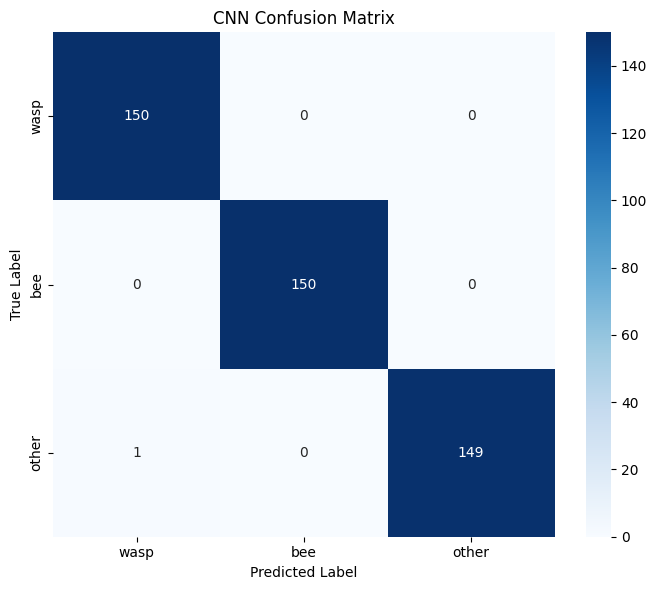

Accuracy    : 0.9978
Precision   : 0.9978
Recall      : 0.9978
Macro F1    : 0.9978
Wasp Recall : 1.0000


In [21]:
'''
CNN Validation 평가
'''

# 클래스별 확률을 예측
cnn_val_pred_probs = cnn_model.predict(X_val_cnn, verbose = 0)

# 가장 큰 확률의 클래스를 최종 예측값으로 사용
cnn_val_pred_classes = np.argmax(cnn_val_pred_probs, axis = 1)

plot_training_history(cnn_history, 'CNN')

cnn_val_result = evaluate_model(y_val_mel, cnn_val_pred_classes, 'CNN')

## 4-3. MobileNetV2

사전 학습된 MobileNetV2 모델을 활용하여 Mel-Spectrogram을 분류한다

- 입력: 128 x 128 x 3 Mel-Spectrogram
- 출력 클래서: wasp / bee / other
- ImageNet 사전 학습 가중치를 활용한 Transfer Learning 사용
- MobileNetV2의 기본 특징 추출층은 동결하여 학습
- CNN 모델과 동일한 Train / Val / Test 데이터를 사용

In [22]:
'''
Mel-Spectrogram 기반 MobileNetV2 분류 모델

- ImageNet으로 사전 학습된 MobileNetV2를 특징 추출기로 사용한다.
- 데이터셋이 작기 때문에 기본 MobileNetV2 층은 동결한다.
- 마지막 분류층만 wasp / bee / other 분류에 맞게 새로 학습한다.
'''

# MobileNetV2 입력 shape
mobilenet_input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 사전 학습된 MobileNetV2 불러오기
mobilenet_base = MobileNetV2(
    input_shape = mobilenet_input_shape,
    include_top = False,
    weights = 'imagenet'
)

# 사전 학습된 특징 추출층 동결
mobilenet_base.trainable = False

# 분류 모델 구성
mobilenet_model = models.Sequential([
    layers.Input(shape = mobilenet_input_shape),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    layers.Dense(len(CLASSES), activation = 'softmax')
])

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
'''
MobileNetV2 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# MobileNetV2 모델 저장 경로
MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'mobilenetv2_best.keras')

# Model Compile
mobilenet_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
mobilenet_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
mobilenet_checkpoint = ModelCheckpoint(
    filepath = MOBILENET_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('MobileNetV2 Model Path: ', MOBILENET_MODEL_PATH)

MobileNetV2 Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras


In [24]:
'''
MobileNetV2 학습
'''

mobilenet_history = mobilenet_model.fit(
    X_train_mobile,
    y_train_mel,
    validation_data = (X_val_mobile, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [mobilenet_early_stopping, mobilenet_checkpoint],
    verbose = 1
)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8334 - loss: 0.4592
Epoch 1: val_loss improved from None to 0.01159, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 135ms/step - accuracy: 0.9390 - loss: 0.1811 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 2/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9916 - loss: 0.0306
Epoch 2: val_loss improved from 0.01159 to 0.00591, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.9957 - loss: 0.0238 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 3/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9991 - loss: 0.0155
Epoch 3: val_loss improved from 0.00591 to 0.00127, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9986 - loss: 0.0126 - val_accurac

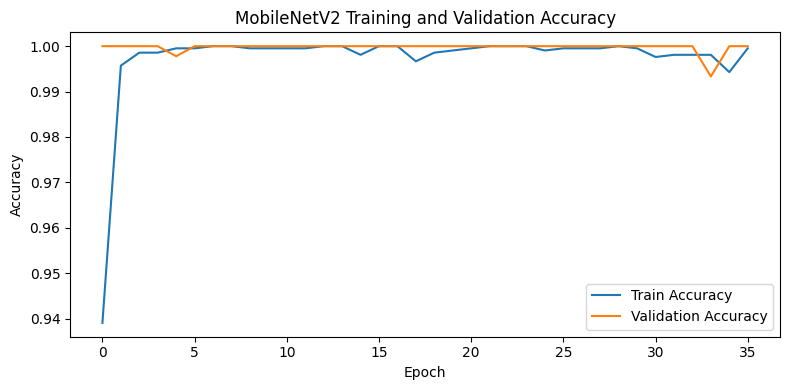

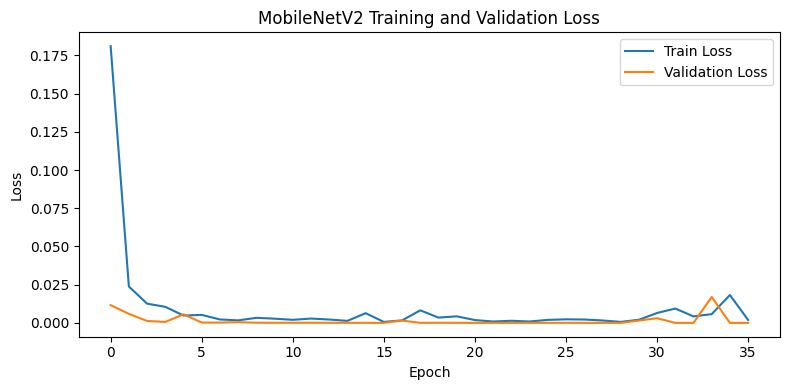

===== MobileNetV2 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



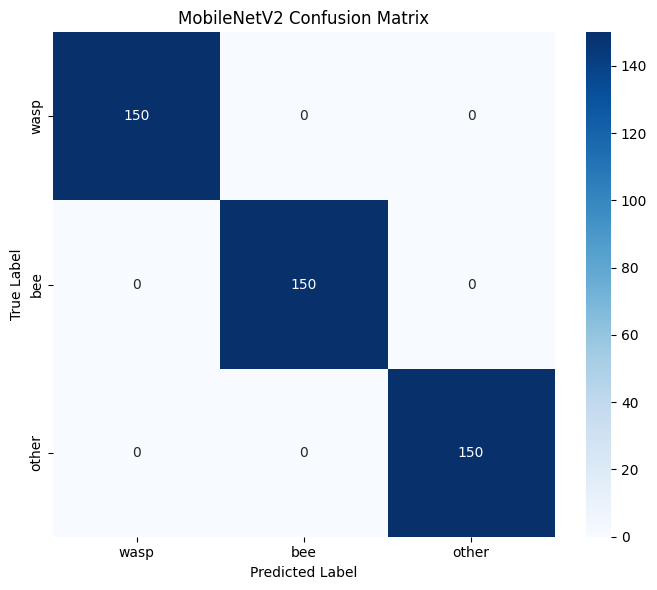

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [25]:
'''
MobileNetV2 Validation 평가
'''

# 클래스 별 확률 예측
mobilenet_val_pred_probs = mobilenet_model.predict(X_val_mobile, verbose = 0)

# 가장 높은 확률의 클래스를 최종 예측값으로 사용
mobilenet_val_pred_classes = np.argmax(mobilenet_val_pred_probs, axis = 1)

plot_training_history(mobilenet_history, 'MobileNetV2')

mobilenet_val_result = evaluate_model(y_val_mel, mobilenet_val_pred_classes, 'MobileNetV2')

## 4-4. CRNN

Mel-Spectrogram의 공간적 특징과 시간적 변화를 함께 학습하기 위해 CNN과 RNN을 결합한 CRNN 모델을 구성한다.

- CNN을 통해 주파수 패턴의 특징을 추출
- RNN(GRU)을 통해 시간에 따른 특징 변화를 학습
- 출력 클래스: wasp / bee / other
- CNN, MobileNetV2와 동일한 Train / Val / Test 데이터 사용

In [26]:
'''
Mel-Spectrogram 기반 CRNN 분류 모델

- CNN으로 Mel-Spectrogram의 주요 특징을 추출한다.
- GRU를 사용하여 시간에 따른 특징 변화를 학습한다.
- wasp / bee / other 3개 클래스를 분류한다.
'''

# CRNN 입력 shape
crnn_input_shape = X_train_crnn.shape[1:]

# 입력층
crnn_input = layers.Input(shape = crnn_input_shape)

# =========================
# CNN Feature 추출
# =========================

x = layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(crnn_input)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

# =========================
# CNN → RNN 형태 변환
# =========================

# 현재 CNN 출력 shape에서 시간 축을 sequence로 사용하도록 변환
shape = x.shape

x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Dense(128, activation = 'relu')(x)

# =========================
# GRU
# =========================

x = layers.GRU(64)(x)

# =========================
# Classification
# =========================

x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

crnn_output = layers.Dense(len(CLASSES), activation = 'softmax')(x)
crnn_model = models.Model(inputs = crnn_input, outputs = crnn_output)

crnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 188, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 188, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 47, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47, 128)        │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,691 (1.23 MB)

 Trainable params: 322,691 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
'''
CRNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CRNN 모델 저장 경로
CRNN_MODEL_PATH = os.path.join(MODEL_DIR, 'crnn_best.keras')

# 모델 컴파일
crnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
crnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
crnn_checkpoint = ModelCheckpoint(
    filepath = CRNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CRNN Model Path: ', CRNN_MODEL_PATH)

CRNN Model Path:  e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras


In [28]:
'''
CRNN 모델 학습
'''

crnn_history = crnn_model.fit(
    X_train_crnn,
    y_train_mel,
    validation_data = (X_val_crnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    callbacks = [crnn_early_stopping, crnn_checkpoint],
    verbose = 1
)

Epoch 1/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5354 - loss: 0.8979
Epoch 1: val_loss improved from None to 0.30577, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.6590 - loss: 0.7081 - val_accuracy: 0.9356 - val_loss: 0.3058
Epoch 2/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9438 - loss: 0.1969
Epoch 2: val_loss improved from 0.30577 to 0.08178, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.9695 - loss: 0.1194 - val_accuracy: 0.9822 - val_loss: 0.0818
Epoch 3/50
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9590 - loss: 0.1278
Epoch 3: val_loss improved from 0.08178 to 0.04377, saving model to e:\AI_First_Team_Project\Buzz\ai_model\models\crnn_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.9700 - loss: 0.0993 - val_accuracy: 0.9889 - val_lo

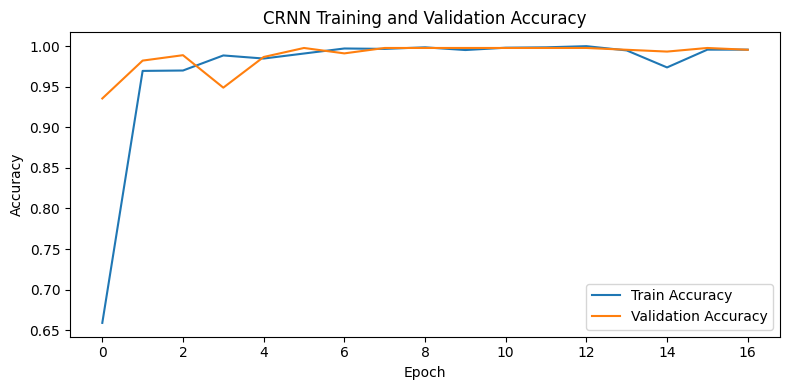

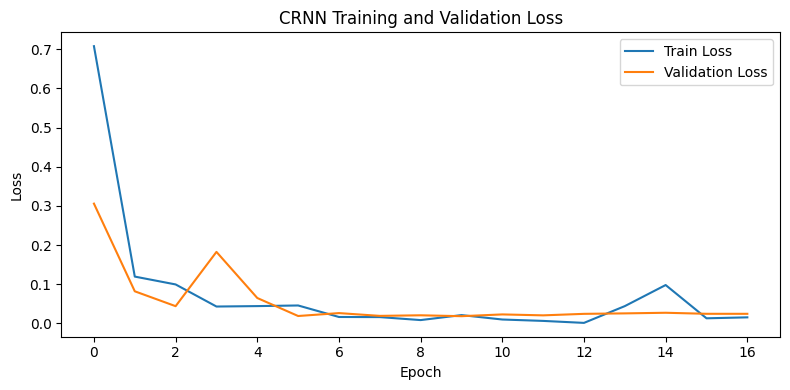

===== CRNN 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       0.99      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      0.99      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



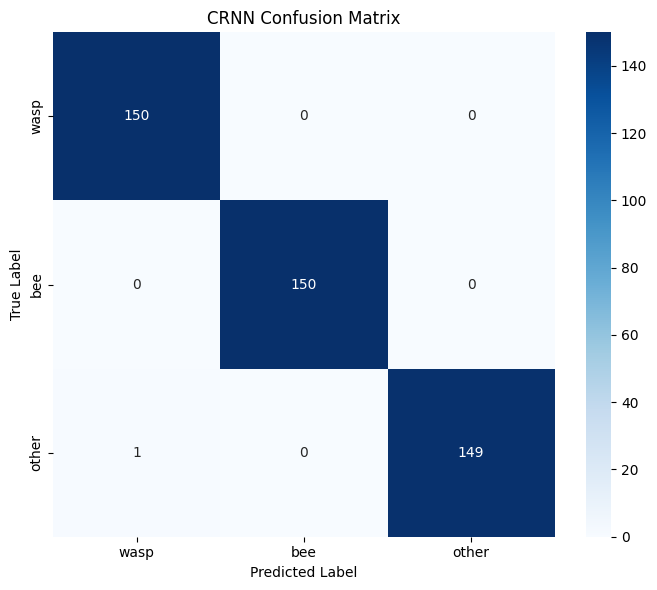

Accuracy    : 0.9978
Precision   : 0.9978
Recall      : 0.9978
Macro F1    : 0.9978
Wasp Recall : 1.0000


In [29]:
'''
CRNN Validation 평가
'''

# 클래스 별 확률 예측
crnn_val_pred_probs = crnn_model.predict(X_val_crnn, verbose = 0)

# 가장 높은 확률의 클래스를 최종 예측값으로 사용
crnn_val_pred_classes = np.argmax(crnn_val_pred_probs, axis = 1)

plot_training_history(crnn_history, 'CRNN')

crnn_val_result = evaluate_model(y_val_mel, crnn_val_pred_classes, 'CRNN')

# 5. Machine Learning

## 5-1. Feature 추출

오디오 파일에서 전통적인 머신러닝 모델이 사용할 수 있도록 고정 길이의 음향 특징을 추출한다.

사용 특징:
- MFCC
- Chroma
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff
- Zero Crossing Rate
- RMS

In [30]:
'''
오디오 파일에서 머신러닝용 음향 특징을 추출
'''

def extract_audio_features_from_audio(y, sr):
    features = []

    # MFCC
    mfcc = librosa.feature.mfcc(y = y, sr = sr, n_mfcc = 20)
    features.extend(np.mean(mfcc, axis = 1))
    features.extend(np.std(mfcc, axis = 1))

    # Chroma
    chroma = librosa.feature.chroma_stft(y = y, sr = sr)
    features.extend(np.mean(chroma, axis = 1))
    features.extend(np.std(chroma, axis = 1))

    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y = y, sr = sr)
    features.append(np.mean(spectral_centroid))
    features.append(np.std(spectral_centroid))

    # Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y = y, sr = sr)
    features.append(np.mean(spectral_bandwidth))
    features.append(np.std(spectral_bandwidth))

    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y = y, sr = sr)
    features.append(np.mean(spectral_rolloff))
    features.append(np.std(spectral_rolloff))

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # RMS
    rms = librosa.feature.rms(y = y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    return np.array(features, dtype = np.float32)

def extract_audio_features(audio_path):
    y, sr = load_audio_file(audio_path, sr = SR, duration = DURATION)
    return extract_audio_features_from_audio(y, sr)

In [31]:
ml_features = []
ml_labels = []
ml_file_paths = []

print('===== Machine Learning Feature 생성 시작 =====')

for class_index, cls in enumerate(CLASSES):
    class_dir = os.path.join(AUDIO_DIR, cls)

    audio_files = glob.glob(os.path.join(class_dir, '*.wav'))

    print(f'{cls}: {len(audio_files)}개 처리중...')

    for audio_file in audio_files:
        try:
            features = extract_audio_features(audio_file)

            ml_features.append(features)
            ml_labels.append(class_index)
            ml_file_paths.append(audio_file)
        except Exception as e:
            print(f'[Warning] Feature 추출 실패: {audio_file}\n원인: {e}')

print('===== Machine Learning Feature 생성 완료 =====')

X_ml = np.array(ml_features, dtype = np.float32)
y_ml = np.array(ml_labels, dtype = np.int32)
ml_file_paths = np.array(ml_file_paths)

print('Feature shape : ', X_ml.shape)
print('Label shape   : ', y_ml.shape)

===== Machine Learning Feature 생성 시작 =====
wasp: 1000개 처리중...
bee: 1000개 처리중...
other: 1000개 처리중...
===== Machine Learning Feature 생성 완료 =====
Feature shape :  (3000, 74)
Label shape   :  (3000,)


In [32]:
'''
Machine Learning 데이터를 Train / Val / Test 기준으로 분리
'''

# 파일 경로 → 인덱스 매핑
path_to_index = {
    path: idx
    for idx, path in enumerate(ml_file_paths)
}

train_indices = [
    path_to_index[path]
    for path in paths_train_mel
]

val_indices = [
    path_to_index[path]
    for path in paths_val_mel
]

test_indices = [
    path_to_index[path]
    for path in paths_test_mel
]

# 데이터 분리
X_train_ml = X_ml[train_indices]
y_train_ml = y_ml[train_indices]

X_val_ml = X_ml[val_indices]
y_val_ml = y_ml[val_indices]

X_test_ml = X_ml[test_indices]
y_test_ml = y_ml[test_indices]

print('Train: ', X_train_ml.shape, y_train_ml.shape)
print('Val  : ', X_val_ml.shape, y_val_ml.shape)
print('Test : ', X_test_ml.shape, y_test_ml.shape)

Train:  (2100, 74) (2100,)
Val  :  (450, 74) (450,)
Test :  (450, 74) (450,)


## 5-2. Random Forest

- RandomForest
> 여러 개의 Decision Tree를 구성하고, 각 Tree의 예측 결과를 종합하여 최종 클래스를 결정하는 앙상블 기반 머신러닝 모델.

In [33]:
'''
RF 분류 모델 학습
'''

rf_model = RandomForestClassifier(n_estimators = 200, random_state = SEED, n_jobs = -1)

rf_model.fit(X_train_ml, y_train_ml)

print('RandomForest 학습 완료')

RandomForest 학습 완료


===== RandomForest 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



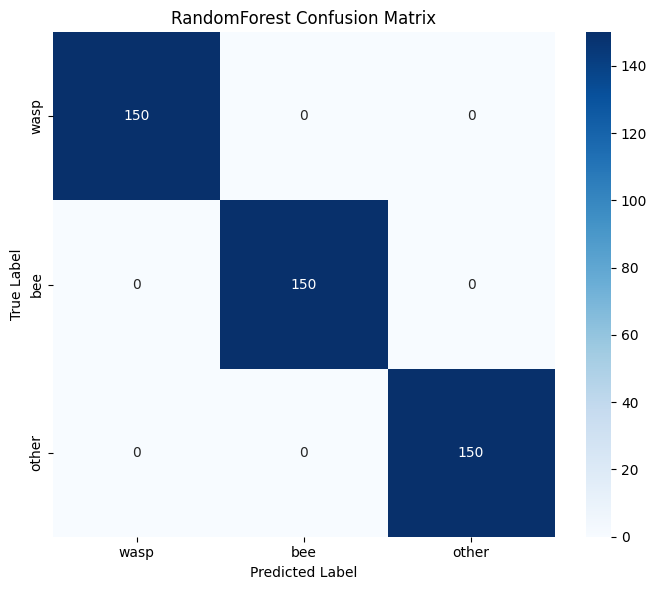

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [34]:
'''
RandomForest Validation 평가
'''

# 예측
rf_val_pred_classes = rf_model.predict(X_val_ml)

rf_val_result = evaluate_model(y_val_ml, rf_val_pred_classes, 'RandomForest')

## 5-3. LightGBM

- Light GBM
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러개의 Decision Tree를 순차적으로 학습하면서 이전 Tree의 오차를 보완하는 방식으로 성능을 개선

In [35]:
'''
LightGBM 분류 모델 학습
'''

lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    random_state = SEED,
    verbosity = -1
)

lgbm_model.fit(X_train_ml, y_train_ml)

print('LightGBM 학습 완료')

LightGBM 학습 완료


===== LightGBM 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



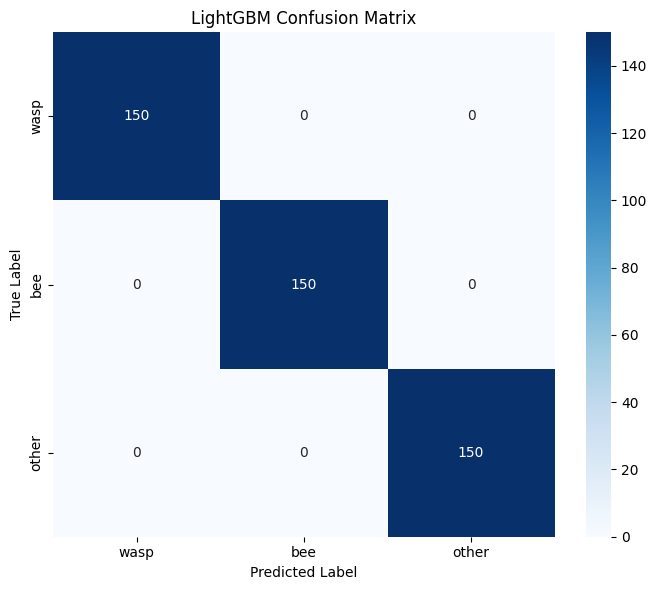

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [36]:
'''
LightGBM Validation 평가
'''

lgbm_val_pred_classes = lgbm_model.predict(X_val_ml)

lgbm_val_result = evaluate_model(y_val_ml, lgbm_val_pred_classes, 'LightGBM')

## 5-4. XGBoost

- XGBoost
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러 개의 Decision Tree를 순차적으로 학습하면서 이전 모델의 오차를 보완하는 방식으로 성능을 개선

In [37]:
'''
XGBoost 분류 모델 학습
'''

xgb_model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = SEED,
    eval_metric = 'mlogloss'
)

xgb_model.fit(X_train_ml, y_train_ml)

print('XGBoost 학습 완료')

XGBoost 학습 완료


===== XGBoost 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



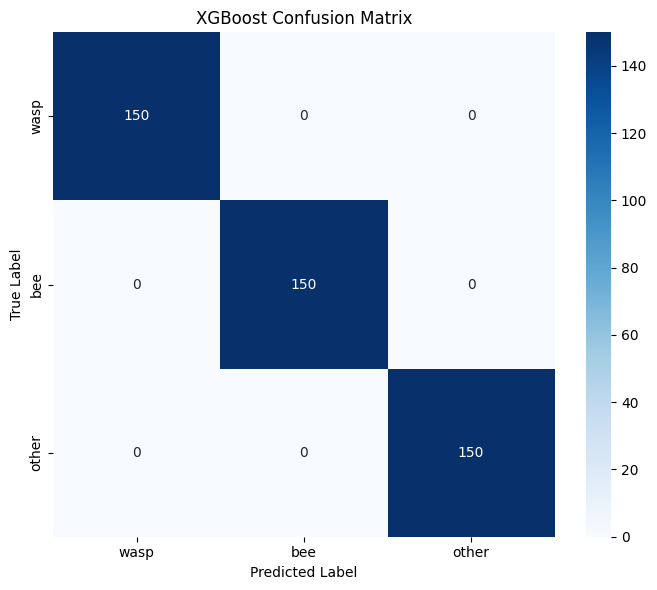

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [38]:
'''
XGBoost Validation 평가
'''

xgb_val_pred_classes = xgb_model.predict(X_val_ml)

xgb_val_result = evaluate_model(y_val_ml, xgb_val_pred_classes, 'XGBoost')

## 5-5. Machine Learning 모델 저장

In [39]:
ensure_directory_exists(MODEL_DIR)

RF_MODEL_PATH = os.path.join(MODEL_DIR, 'randomforest.pkl')
LGBM_MODEL_PATH = os.path.join(MODEL_DIR, 'lightgbm.pkl')
XGB_MODEL_PATH = os.path.join(MODEL_DIR, 'xgboost.pkl')

joblib.dump(rf_model, RF_MODEL_PATH)
joblib.dump(lgbm_model, LGBM_MODEL_PATH)
joblib.dump(xgb_model, XGB_MODEL_PATH)

print('===== Machine Learning 모델 저장 완료 =====')
print('RandomForest : ', RF_MODEL_PATH)
print('LightGBM     : ', LGBM_MODEL_PATH)
print('XGBoost      : ', XGB_MODEL_PATH)

===== Machine Learning 모델 저장 완료 =====
RandomForest :  e:\AI_First_Team_Project\Buzz\ai_model\models\randomforest.pkl
LightGBM     :  e:\AI_First_Team_Project\Buzz\ai_model\models\lightgbm.pkl
XGBoost      :  e:\AI_First_Team_Project\Buzz\ai_model\models\xgboost.pkl


# 6. 모델 성능 비교 및 최종 추론 방식 선정

학습한 모델들의 Validation 성능을 동일한 평가 지표로 비교

- Accuracy
- Precision
- Recall
- Macro F1
- Wasp Recall

Validation 결과를 기준으로 Best Single Model을 선정하고, 이후 Ensemble 방식과 비교하여 최종 추론 방식을 결정

In [40]:
'''
Validation 기준 모델 성능 비교
'''

validation_results = pd.DataFrame([
    cnn_val_result,
    mobilenet_val_result,
    crnn_val_result,
    rf_val_result,
    lgbm_val_result,
    xgb_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준으로 정렬
validation_results = validation_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Validation 모델 성능 비교 =====')
display(validation_results)

# Best Single Model 선정
best_model_name = validation_results.loc[0, 'Model']

print('===== Best Single Model =====')
print(best_model_name)

===== Validation 모델 성능 비교 =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall
0,MobileNetV2,1.000000,1.000000,1.000000,1.000000,1.0
1,RandomForest,1.000000,1.000000,1.000000,1.000000,1.0
2,LightGBM,1.000000,1.000000,1.000000,1.000000,1.0
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.0
4,CNN,0.997778,0.997792,0.997778,0.997778,1.0
5,CRNN,0.997778,0.997792,0.997778,0.997778,1.0


===== Best Single Model =====
MobileNetV2


===== Ensemble 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



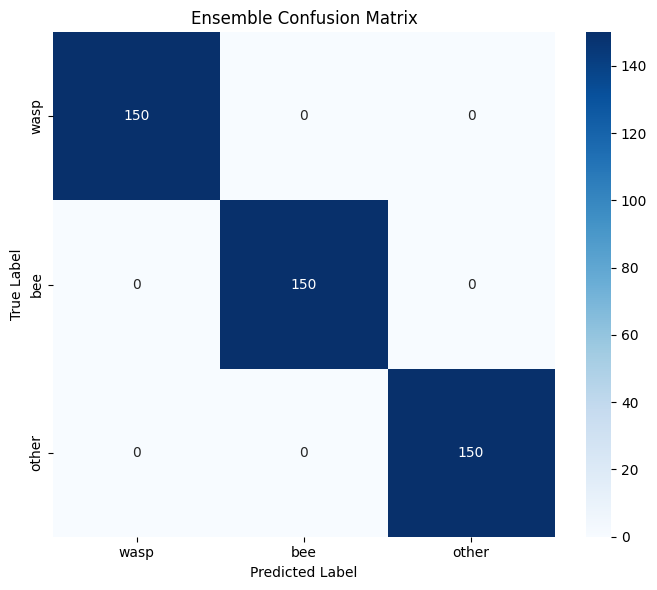

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000


In [41]:
'''
Soft Voting Ensemble Validation 평가

6개 모델의 클래스별 예측 확률을 평균하여 최종 클래스를 결정
'''

# Machine Learning 모델의 Validation 예측 확률
rf_val_pred_probs = rf_model.predict_proba(X_val_ml)
lgbm_val_pred_probs = lgbm_model.predict_proba(X_val_ml)
xgb_val_pred_probs = xgb_model.predict_proba(X_val_ml)

# Deep Learning + Machine Learning 6개 모델의 확률 평균
ensemble_val_pred_probs = np.mean([
    cnn_val_pred_probs,
    mobilenet_val_pred_probs,
    crnn_val_pred_probs,
    rf_val_pred_probs,
    lgbm_val_pred_probs,
    xgb_val_pred_probs
], axis = 0)

# 가장 높은 평균 확률을 최종 클래스로 선택
ensemble_val_pred_classes = np.argmax(ensemble_val_pred_probs, axis = 1)

# Ensemble Validation 성능 평가
ensemble_val_result = evaluate_model(y_val_mel, ensemble_val_pred_classes, 'Ensemble')

In [42]:
'''
Best Single Model vs Ensemble 비교

Validation 성능을 기준으로 최종 추론 방식 결정
'''

# Best Single Model 결과
best_single_result = validation_results.iloc[0].to_dict()

# 비교용 DataFrame
final_method_results = pd.DataFrame([
    best_single_result,
    ensemble_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준
final_method_results = final_method_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Best Single Model vs Ensemble =====')
display(final_method_results)

# 최종 추론 방식 결정
final_method_name = final_method_results.loc[0, 'Model']

if final_method_name == 'Ensemble':
    final_inference_type = 'ensemble'
    final_model_name = None
else:
    final_inference_type = 'single'
    final_model_name = final_method_name

print('===== 최종 추론 방식 =====')
if final_inference_type == 'ensemble':
    print('Ensemble')
else:
    print(f'Best Single Model : {final_model_name}')

===== Best Single Model vs Ensemble =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall
0,MobileNetV2,1.0,1.0,1.0,1.0,1.0
1,Ensemble,1.0,1.0,1.0,1.0,1.0


===== 최종 추론 방식 =====
Best Single Model : MobileNetV2


===== MobileNetV2 분류 리포트 =====
              precision    recall  f1-score   support

        wasp       1.00      1.00      1.00       150
         bee       1.00      1.00      1.00       150
       other       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



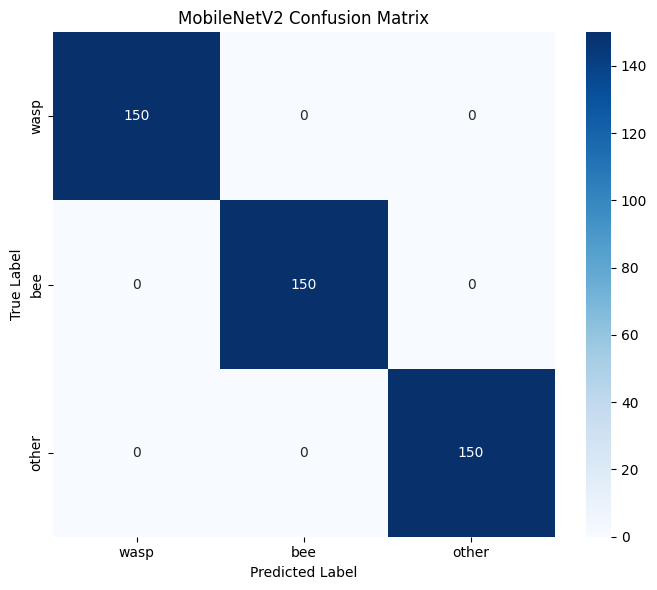

Accuracy    : 1.0000
Precision   : 1.0000
Recall      : 1.0000
Macro F1    : 1.0000
Wasp Recall : 1.0000
===== 최종 Test 결과 =====
최종 추론 방식 : MobileNetV2


In [43]:
'''
최종 추론 방식 Test 평가

Validation에서 결정된 최종 추론 방식을 Test 데이터로 마지막 한 번 더 평가
'''

if final_inference_type == 'ensemble':
    # Deep Learning 모델 Test 예측 확률
    cnn_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
    mobilenet_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
    crnn_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)

    # Machine Learning 모델 Test 예측 확률
    rf_test_pred_probs = rf_model.predict_proba(X_test_ml)
    lgbm_test_pred_probs = lgbm_model.predict_proba(X_test_ml)
    xgb_test_pred_probs = xgb_model.predict_proba(X_test_ml)

    # Soft Voting
    final_test_pred_probs = np.mean([
        cnn_test_pred_probs,
        mobilenet_test_pred_probs,
        crnn_test_pred_probs,
        rf_test_pred_probs,
        lgbm_test_pred_probs,
        xgb_test_pred_probs
    ], axis = 0)

    final_test_pred_classes = np.argmax(final_test_pred_probs, axis = 1)

    final_test_name = 'Ensemble'
else:
    if final_model_name == 'CNN':
        final_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
        final_test_pred_classes = np.argmax(final_test_pred_probs, axis = 1)
    elif final_model_name == 'MobileNetV2':
        final_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
        final_test_pred_classes = np.argmax(final_test_pred_probs, axis = 1)
    elif final_model_name == 'CRNN':
        final_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)
        final_test_pred_classes = np.argmax(final_test_pred_probs, axis = 1)
    elif final_model_name == 'RandomForest':
        final_test_pred_probs = rf_model.predict_proba(X_test_ml)
        final_test_pred_classes = rf_model.predict(X_test_ml)
    elif final_model_name == 'LightGBM':
        final_test_pred_probs = lgbm_model.predict_proba(X_test_ml)
        final_test_pred_classes = lgbm_model.predict(X_test_ml)
    elif final_model_name == 'XGBoost':
        final_test_pred_probs = xgb_model.predict_proba(X_test_ml)
        final_test_pred_classes = xgb_model.predict(X_test_ml)
    else:
        raise ValueError(f'지원하지 않는 모델입니다: {final_model_name}')

    final_test_name = final_model_name

# 최종 Test 평가
final_test_result = evaluate_model(y_test_mel, final_test_pred_classes, final_test_name)

print('===== 최종 Test 결과 =====')
print(f'최종 추론 방식 : {final_test_name}')

# 7. 최종 추론 및 UI 데이터 생성

임의의 WAV 파일 하나를 입력받아 모델 예측 결과와
UI 시각화에 필요한 Waveform, FFT, Spectrogram 데이터를 생성한다.

반환 데이터:
- 예측 클래스
- 예측 확률
- 클래스별 확률
- Waveform
- FFT
- Mel-Spectrogram

In [44]:
'''
UI용 분석 데이터 생성 함수

- 예측에 사용한 동일한 오디오 y, sr을 사용
- Waveform / FFT 데이터는 UI 전송량을 줄이기 위해 다운샘플링
- 반환 데이터는 JSON 직렬화가 가능하도록 list 형태로 변환
'''

def downsample_1d(x, y, max_points = 2000):
    if len(x) <= max_points:
        return x, y

    indices = np.linspace(
        0,
        len(x) -1,
        max_points,
        dtype = int
    )

    return x[indices], y[indices]

def create_audio_visualization_data(y, sr):
    # =========================
    # Waveform
    # =========================

    waveform_time = np.arange(len(y)) / sr

    waveform_time, waveform_amplitude = downsample_1d(
        waveform_time,
        y,
        max_points = 2000
    )

    # =========================
    # FFT
    # =========================

    fft_values = np.fft.rfft(y)
    fft_magnitude = np.abs(fft_values)
    fft_frequency = np.fft.rfftfreq(len(y), d = 1 / sr)

    # UI 에서는 0 ~ 8000 Hz 구간만 사용
    fft_mask = fft_frequency <= 8000
    fft_frequency = fft_frequency[fft_mask]
    fft_magnitude = fft_magnitude[fft_mask]

    fft_frequency, fft_magnitude = downsample_1d(
        fft_frequency,
        fft_magnitude,
        max_points = 2000
    )

    # =========================
    # Mel-Spectrogram
    # =========================

    mel_spec_db = create_mel_spectrogram_from_audio(y, sr)

    # Spectrogram 시간축
    spec_times = librosa.frames_to_time(
        np.arange(mel_spec_db.shape[1]),
        sr = sr,
        hop_length = HOP_LENGTH
    )

    # Mel 주파수 축
    spec_frequencies = librosa.mel_frequencies(n_mels = N_MELS, fmin = 0, fmax = sr / 2)

    # =========================
    # JSON 반환 구조
    # =========================

    return {
        'waveform': {
            'time': waveform_time.tolist(),
            'amplitude': waveform_amplitude.tolist()
        },
        'fft': {
            'frequency': fft_frequency.tolist(),
            'magnitude': fft_magnitude.tolist()
        },
        'spectrogram': {
            'time': spec_times.tolist(),
            'frequency': spec_frequencies.tolist(),
            'values': mel_spec_db.tolist()
        }
    }

In [45]:
'''
CNN 추론 함수
'''

def predict_with_cnn(y, sr):
    mel = create_mel_spectrogram_from_audio(y, sr)
    model_input = prepare_cnn_dataset(np.array([mel], dtype = np.float32))
    probs = cnn_model.predict(model_input, verbose = 0)[0]
    pred_index = int(np.argmax(probs))

    return {
        'prediction': idx_to_class[pred_index],
        'confidence': float(probs[pred_index]),
        'probabilities': probs
    }

In [46]:
'''
MobileNetV2 추론 함수
'''

def predict_with_mobilenet(y, sr):
    mel = create_mel_spectrogram_from_audio(y, sr)
    model_input = prepare_mobilenet_dataset(np.array([mel], dtype = np.float32))
    probs = mobilenet_model.predict(model_input, verbose = 0)[0]
    pred_index = int(np.argmax(probs))

    return {
        'prediction': idx_to_class[pred_index],
        'confidence': float(probs[pred_index]),
        'probabilities': probs
    }

In [47]:
'''
CRNN 추론 함수
'''

def predict_with_crnn(y, sr):
    mel = create_mel_spectrogram_from_audio(y, sr)
    model_input = prepare_crnn_dataset(np.array([mel], dtype = np.float32))
    probs = crnn_model.predict(model_input, verbose = 0)[0]
    pred_index = int(np.argmax(probs))
    
    return {
        'prediction': idx_to_class[pred_index],
        'confidence': float(probs[pred_index]),
        'probabilities': probs
    }

In [48]:
'''
Machine Learning 공통 WAV 추론 함수
'''

def predict_with_ml_model(y, sr, model):
    features = extract_audio_features_from_audio(y, sr).reshape(1, -1)

    probs = model.predict_proba(features)[0]
    pred_index = int(np.argmax(probs))

    return {
        'prediction': idx_to_class[pred_index],
        'confidence': float(probs[pred_index]),
        'probabilities': probs
    }

In [49]:
'''
6개 모델 Soft Voting Ensemble 추론
'''

def predict_with_ensemble(y, sr):
    cnn_result = predict_with_cnn(y, sr)
    mobilenet_result = predict_with_mobilenet(y, sr)
    crnn_result = predict_with_crnn(y, sr)
    rf_result = predict_with_ml_model(y, sr, rf_model)
    lgbm_result = predict_with_ml_model(y, sr, lgbm_model)
    xgb_result = predict_with_ml_model(y, sr, xgb_model)

    ensemble_probs = np.mean([
        cnn_result['probabilities'],
        mobilenet_result['probabilities'],
        crnn_result['probabilities'],
        rf_result['probabilities'],
        lgbm_result['probabilities'],
        xgb_result['probabilities'],
    ], axis = 0)

    pred_index = int(np.argmax(ensemble_probs))

    return {
        'prediction': idx_to_class[pred_index],
        'confidence': float(ensemble_probs[pred_index]),
        'probabilities': ensemble_probs
    }

In [50]:
'''
신규 Audio 분석

- 오디오 파일 한 번만 로드
- Validation에서 결정된 최종 추론 방식을 사용
- 예측과 UI 시각화 데이터에 동일한 오디오 구간을 사용
'''

def analyze_audio(audio_path):
    # =========================
    # Audio 1회 Load
    # =========================

    y, sr = load_audio_file(audio_path, sr = SR, duration = DURATION)

    # =========================
    # 최종 모델 추론
    # =========================

    if final_inference_type == 'ensemble':
        prediction_result = predict_with_ensemble(y, sr)
        used_model = 'Ensemble'

    else:
        if final_model_name == 'CNN':
            prediction_result = predict_with_cnn(y, sr)

        elif final_model_name == 'MobileNetV2':
            prediction_result = predict_with_mobilenet(y, sr)

        elif final_model_name == 'CRNN':
            prediction_result = predict_with_crnn(y, sr)

        elif final_model_name == 'RandomForest':
            prediction_result = predict_with_ml_model(y, sr, rf_model)

        elif final_model_name == 'LightGBM':
            prediction_result = predict_with_ml_model(y, sr, lgbm_model)

        elif final_model_name == 'XGBoost':
            prediction_result = predict_with_ml_model(y, sr, xgb_model)

        else:
            raise ValueError(f'지원하지 않는 모델입니다: {final_model_name}')

        used_model = final_model_name

    # =========================
    # UI 시각화 데이터
    # =========================

    visualization_data = create_audio_visualization_data(y, sr)

    # =========================
    # UI 반환용 확률 구조
    # =========================

    probabilities = {
        CLASSES[i]: float(prediction_result['probabilities'][i])
        for i in range(len(CLASSES))
    }


    return {
        'model': used_model,
        'prediction': prediction_result['prediction'],
        'confidence': prediction_result['confidence'],
        'probabilities': probabilities,
        **visualization_data
    }

In [54]:
test_audio_path = r"E:\1st_project\sound\temp\Vespa_crabro_C0004_17set2020_I.wav"
# os.path.join(AUDIO_DIR, 'wasp', 'wasp_001.wav') 처럼 입력하면 됨
# 랜덤 테스트 - random.choice(paths_test_mel)

result = analyze_audio(test_audio_path)

print('===== 추론 결과 =====')
print('파일: ', test_audio_path)
print('사용 모델: ', result['model'])
print('예측: ', result['prediction'])
print(f"신뢰도: {result['confidence']:.4f}")
print('확률: ', result['probabilities'])

===== 추론 결과 =====
파일:  E:\1st_project\sound\temp\Vespa_crabro_C0004_17set2020_I.wav
사용 모델:  MobileNetV2
예측:  wasp
신뢰도: 1.0000
확률:  {'wasp': 1.0, 'bee': 1.4670649948773234e-13, 'other': 3.657437200321745e-11}
